GURU PRASAD N 24BAD039

# RNN for Text Generation using Tiny Shakespeare

## Task A - Dataset Preparation

In [1]:
import os
import random
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
import requests

# Load Tiny Shakespeare directly from the raw text file
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

response = requests.get(url)
response.raise_for_status()

train_text = response.text

print("Dataset loaded successfully")
print("\nNumber of characters in training text:", len(train_text))

print("\nFirst 1000 characters:\n")
print(train_text[:1000])

Dataset loaded successfully

Number of characters in training text: 1115394

First 1000 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, 

In [3]:
# Explore basic properties of the text
lines = [line.strip() for line in train_text.splitlines() if line.strip()]

print("Number of non-empty lines:", len(lines))
print("\nFirst 10 non-empty lines:")
for i, line in enumerate(lines[:10], start=1):
    print(f"{i}: {line}")

Number of non-empty lines: 32777

First 10 non-empty lines:
1: First Citizen:
2: Before we proceed any further, hear me speak.
3: All:
4: Speak, speak.
5: First Citizen:
6: You are all resolved rather to die than to famish?
7: All:
8: Resolved. resolved.
9: First Citizen:
10: First, you know Caius Marcius is chief enemy to the people.


In [4]:
# Convert to lowercase and perform light normalization.
# We retain apostrophes inside words, while replacing other punctuation with spaces.
text = train_text.lower()
text = re.sub(r"[^a-z'\s]", " ", text)
text = re.sub(r"\s+", " ", text).strip()

print("Cleaned text sample:\n")
print(text[:1000])

Cleaned text sample:

first citizen before we proceed any further hear me speak all speak speak first citizen you are all resolved rather to die than to famish all resolved resolved first citizen first you know caius marcius is chief enemy to the people all we know't we know't first citizen let us kill him and we'll have corn at our own price is't a verdict all no more talking on't let it be done away away second citizen one word good citizens first citizen we are accounted poor citizens the patricians good what authority surfeits on would relieve us if they would yield us but the superfluity while it were wholesome we might guess they relieved us humanely but they think we are too dear the leanness that afflicts us the object of our misery is as an inventory to particularise their abundance our sufferance is a gain to them let us revenge this with our pikes ere we become rakes for the gods know i speak this in hunger for bread not in thirst for revenge second citizen would you proceed

In [5]:
# Tokenize the complete text into words.
# filters='' is used because punctuation was already handled during cleaning.
tokenizer = Tokenizer(filters="", lower=False, oov_token="<OOV>")
tokenizer.fit_on_texts([text])

word_to_index = tokenizer.word_index
index_to_word = {index: word for word, index in word_to_index.items()}

# +1 because index 0 is reserved for padding.
vocab_size = len(word_to_index) + 1

token_ids = tokenizer.texts_to_sequences([text])[0]

print("Vocabulary size (including padding index 0):", vocab_size)
print("Total word tokens:", len(token_ids))
print("\nFirst 20 vocabulary entries:")
for word, idx in list(word_to_index.items())[:20]:
    print(f"{word:15s} -> {idx}")

Vocabulary size (including padding index 0): 12633
Total word tokens: 204062

First 20 vocabulary entries:
<OOV>           -> 1
the             -> 2
and             -> 3
to              -> 4
i               -> 5
of              -> 6
you             -> 7
my              -> 8
a               -> 9
that            -> 10
in              -> 11
is              -> 12
not             -> 13
for             -> 14
with            -> 15
me              -> 16
it              -> 17
be              -> 18
your            -> 19
his             -> 20


In [6]:
# Generate variable-length sequences for next-word prediction.
# At most 10 previous words are used to predict the next word.
MAX_CONTEXT = 10
sequences = []

for i in range(1, len(token_ids)):
    start = max(0, i - MAX_CONTEXT)
    sequence = token_ids[start:i + 1]   # context words + target word
    sequences.append(sequence)

# All sequences are padded to MAX_CONTEXT + 1:
# first MAX_CONTEXT positions = input, final position = target.
max_sequence_len = MAX_CONTEXT + 1

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_sequence_len,
    padding="pre",
    truncating="pre"
)

print("Number of sequences:", len(padded_sequences))
print("Padded sequence shape:", padded_sequences.shape)
print("\nExample padded sequences:")
print(padded_sequences[:5])

Number of sequences: 204061
Padded sequence shape: (204061, 11)

Example padded sequences:
[[  0   0   0   0   0   0   0   0   0  89 270]
 [  0   0   0   0   0   0   0   0  89 270 140]
 [  0   0   0   0   0   0   0  89 270 140  36]
 [  0   0   0   0   0   0  89 270 140  36 969]
 [  0   0   0   0   0  89 270 140  36 969 144]]


In [7]:
# Separate predictors (X) and next-word labels (y)
X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Shuffle before splitting
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

# 80% training, 20% validation
split_index = int(0.8 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]
X_val = X[split_index:]
y_val = y[split_index:]

print("\nTraining samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Input sequence length:", X_train.shape[1])
print("Nitheeswaran M 24BAD079")

X shape: (204061, 10)
y shape: (204061,)

Training samples: 163248
Validation samples: 40813
Input sequence length: 10
Nitheeswaran M 24BAD079


## Task B - Implementing the RNN Model

Architecture:

**Word IDs → Embedding → SimpleRNN → Dense Softmax**

In [8]:
EMBEDDING_DIM = 100
RNN_UNITS = 128

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_CONTEXT,
        mask_zero=True
    ),
    SimpleRNN(RNN_UNITS),
    Dense(vocab_size, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Build explicitly so the full summary is displayed consistently.
model.build(input_shape=(None, MAX_CONTEXT))
model.summary()
print("Nitheeswaran M 24BAD079")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1789569534.695766      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789569534.698912      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 100)        │     1,263,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12633)          │     1,629,657 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,922,269 (11.15 MB)

 Trainable params: 2,922,269 (11.15 MB)

 Non-trainable params: 0 (0.00 B)

Nitheeswaran M 24BAD079


## Task C - Model Training and Performance Evaluation

In [9]:
EPOCHS = 15
BATCH_SIZE = 128

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
  40/1276 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0152 - loss: 8.9922    

I0000 00:00:1789569540.569536     110 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1276/1276 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.0424 - loss: 6.7906 - val_accuracy: 0.0645 - val_loss: 6.4792
Epoch 2/15
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.0772 - loss: 6.1317 - val_accuracy: 0.0803 - val_loss: 6.3295
Epoch 3/15
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.0926 - loss: 5.7826 - val_accuracy: 0.0855 - val_loss: 6.3238
Epoch 4/15
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1043 - loss: 5.4967 - val_accuracy: 0.0854 - val_loss: 6.3729
Epoch 5/15
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1162 - loss: 5.2377 - val_accuracy: 0.0845 - val_loss: 6.4478
Epoch 6/15
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1301 - loss: 4.9972 - val_accuracy: 0.0840 - val_loss: 6.5402


In [10]:
# Record final metrics
final_train_accuracy = history.history["accuracy"][-1]
final_val_accuracy = history.history["val_accuracy"][-1]
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print(f"Training Accuracy   : {final_train_accuracy:.4f}")
print(f"Validation Accuracy : {final_val_accuracy:.4f}")
print(f"Training Loss       : {final_train_loss:.4f}")
print(f"Validation Loss     : {final_val_loss:.4f}")

Training Accuracy   : 0.1301
Validation Accuracy : 0.0840
Training Loss       : 4.9972
Validation Loss     : 6.5402


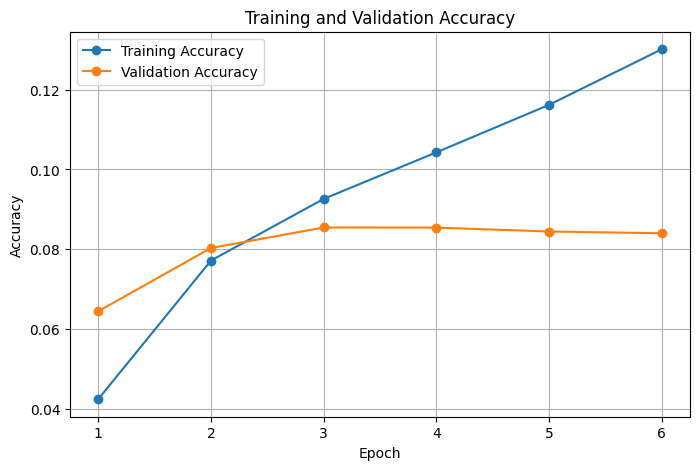

Nitheeswaran M 24BAD079


In [11]:
# Accuracy vs Epoch
epochs_ran = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(epochs_ran, history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()
print("Nitheeswaran M 24BAD079")

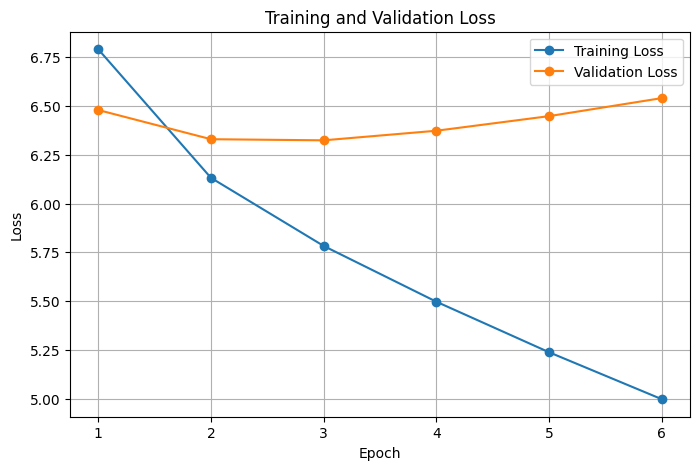

Nitheeswaran M 24BAD079


In [12]:
# Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["loss"], marker="o", label="Training Loss")
plt.plot(epochs_ran, history.history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()
print("Nitheeswaran M 24BAD079")

## Task D - Text Generation

Instead of always choosing the highest-probability word, the function below can sample from the predicted probability distribution using a **temperature** value.

- Lower temperature (e.g. 0.5): safer and more repetitive.
- Around 1.0: more diverse.
- Higher temperature: more random.

In [13]:
def sample_next_word(probabilities, temperature=0.8):
    probabilities = np.asarray(probabilities).astype("float64")

    # Avoid numerical problems with log(0)
    probabilities = np.log(probabilities + 1e-10) / temperature
    probabilities = np.exp(probabilities)
    probabilities = probabilities / np.sum(probabilities)

    return np.random.choice(len(probabilities), p=probabilities)


def generate_text(seed_text, next_words=30, temperature=0.8):
    generated_text = seed_text.lower().strip()

    for _ in range(next_words):
        # Apply the same cleaning used during training.
        cleaned_seed = re.sub(r"[^a-z'\s]", " ", generated_text)
        cleaned_seed = re.sub(r"\s+", " ", cleaned_seed).strip()

        token_list = tokenizer.texts_to_sequences([cleaned_seed])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=MAX_CONTEXT,
            padding="pre",
            truncating="pre"
        )

        predicted_probabilities = model.predict(token_list, verbose=0)[0]

        # Padding index 0 should never be generated.
        predicted_probabilities[0] = 0

        predicted_index = sample_next_word(
            predicted_probabilities,
            temperature=temperature
        )

        predicted_word = index_to_word.get(predicted_index)

        if predicted_word is None or predicted_word == "<OOV>":
            continue

        generated_text += " " + predicted_word

    return generated_text

In [14]:
# Generate multiple samples with different seeds
seeds = [
    "to be or not to be",
    "romeo",
    "my lord",
    "the king"
]

for seed in seeds:
    print("=" * 90)
    print("Seed:", seed)
    print("Generated text:")
    print(generate_text(seed, next_words=40, temperature=0.8))
    print()

Seed: to be or not to be
Generated text:
to be or not to be rivers yet thou be dispatch'd to read their own house where he shall not thee then in one brain in the tongue and that have made it is a form to pieces my breathing blood and no more weeds we

Seed: romeo
Generated text:
romeo should garden that draught rather not not deny in full of arms and i may have too unto my counsel shall by her clarence gloucester is in peace good lord edward i do you had guess katharina did you never

Seed: my lord
Generated text:
my lord the sweetest aumerle i am no more marcius shall be friendly matter he for it isabella well he see me to go gloucester welcome go lady anne you advise you so rather i am good sweet king richard iii my

Seed: the king
Generated text:
the king lewis vi then and us straight for my cousin is your gentleman that were it call him like my lord this company henry margaret is and till be gone baptista i will give you to morrow lady anne me have



In [15]:
# Optional experiment: compare temperatures
seed = "to be or not to be"

for temperature in [0.5, 0.8, 1.2]:
    print("=" * 90)
    print(f"Temperature = {temperature}")
    print(generate_text(seed, next_words=40, temperature=temperature))
    print()

Temperature = 0.5
to be or not to be a most man of my head and to a market death and are a woman to the market night and shall not the crown to the king of york as i am not to your ignorant king richard iii what

Temperature = 0.8
to be or not to be fight of my wagoner queen margaret of your hands and all my son and my business wilt to my lord i have myself you take it to your leave of joy against the prince and there is your man have

Temperature = 1.2
to be or not to be dead are cabin a parasite to such red confirm caetera camillo both sir but stop remember hence and turn your freedom sebastian i do have been would am think isabel no news ' ay leontes i would visit open our



In [16]:
# Save the trained model
model.save("tiny_shakespeare_rnn.keras")
print("Model saved as tiny_shakespeare_rnn.keras")
print("Nitheeswaran M 24BAD079")

Model saved as tiny_shakespeare_rnn.keras
Nitheeswaran M 24BAD079
